RAM check
!free -h
Disk check
!df -h
GPU check (agar enable kiya ho to)
!nvidia-smi

# 1. Exploratory Data Analysis

In [ ]:
import pandas as pd

df=pd.read_csv('diabetes.csv')
print(df.head())

# Basic exploration
print(f'Shape: {df.shape}')
print(f'\nColumn names:\n{df.columns.tolist()}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nBasic statistics:\n{df.describe()}')
print(f'\nOutcome distribution:\n{df["Outcome"].value_counts()}')


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness             

# Visualization of data for better understanding

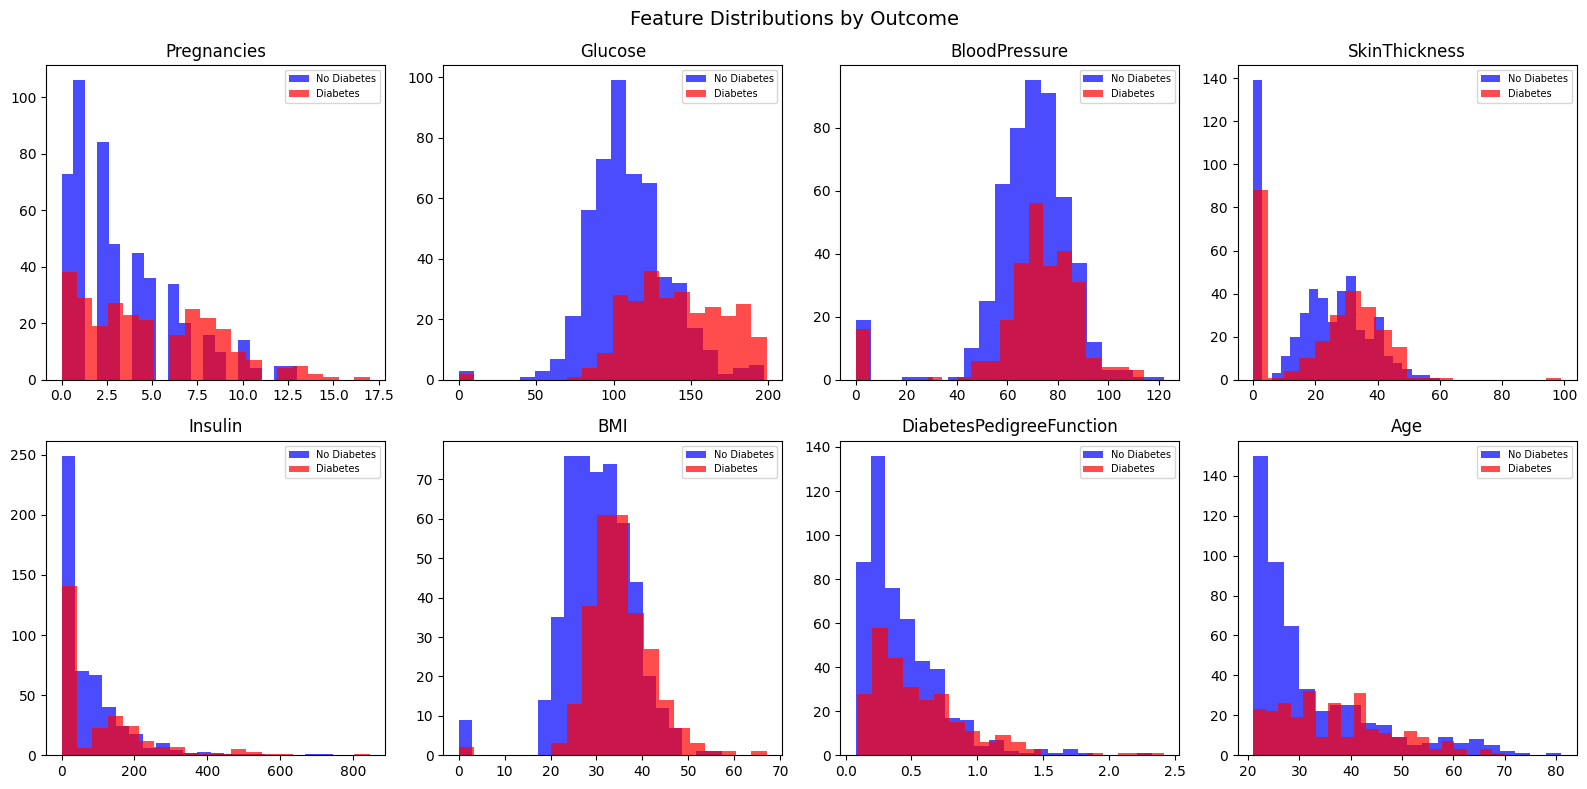

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

features = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']

for i, feature in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][feature],
                 bins=20, alpha=0.7,
                 color='blue', label='No Diabetes')
    axes[i].hist(df[df['Outcome']==1][feature],
                 bins=20, alpha=0.7,
                 color='red', label='Diabetes')
    axes[i].set_title(feature)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Outcome', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np


zero_not_allowed = ['Glucose', 'BloodPressure',
                    'SkinThickness', 'Insulin', 'BMI']

# Count zeros in each column
print("Zero counts before fixing:")
for col in zero_not_allowed:
    zeros = (df[col] == 0).sum()
    print(f'{col}: {zeros} zeros')

df[zero_not_allowed]=df[zero_not_allowed].replace(0,np.nan)
df[zero_not_allowed].isnull().sum(axis=0)

Zero counts before fixing:
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


# 2. Data Preprocessing & Median Imputation

In [ ]:
from sklearn.impute import SimpleImputer
# Use median — more robust than mean for medical data
imputer = SimpleImputer(strategy='median')
df[zero_not_allowed] = imputer.fit_transform(df[zero_not_allowed])

# Verify no more missing values
print("Missing values after imputation:")
print(df.isnull().sum())
print(f"\nInsulin stats after fixing:")
print(df['Insulin'].describe())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Insulin stats after fixing:
count    768.000000
mean     140.671875
std       86.383060
min       14.000000
25%      121.500000
50%      125.000000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64


### Visualization for an outliers

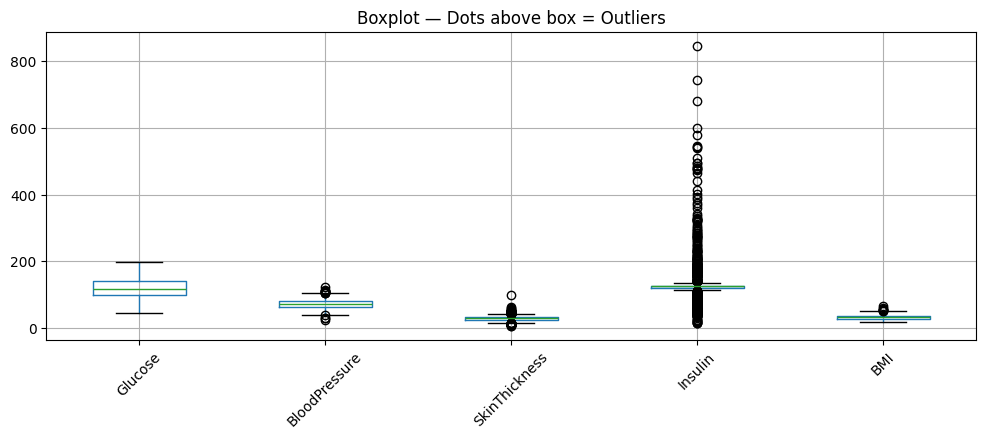

In [ ]:

plt.figure(figsize=(12, 4))
df[zero_not_allowed].boxplot()
plt.title('Boxplot — Dots above box = Outliers')
plt.xticks(rotation=45)
plt.show()

# 3. Test/train data splitting

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 4a — Separate features and label
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f'Features shape: {X.shape}')
print(f'Label shape: {y.shape}')
print(f'\nFeature names: {X.columns.tolist()}')
print(f'\nLabel distribution:\n{y.value_counts()}')

# Step 4b — Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')
print(f'\nTrain label distribution:\n{y_train.value_counts()}')
print(f'Test label distribution:\n{y_test.value_counts()}')

Features shape: (768, 8)
Label shape: (768,)

Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Label distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Training samples: 614
Testing samples:  154

Train label distribution:
Outcome
0    400
1    214
Name: count, dtype: int64
Test label distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


# 4. Pipeline processing and scaling

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline=Pipeline([
    ('scaler',StandardScaler())
])
x_train_clean=pipeline.fit_transform(X_train)
print(f'After Scaling x_train data\n {x_train_clean}')
print(x_train_clean.shape)
x_test_clean=pipeline.transform(X_test)
print(f'After Scaling x_test data\n {x_test_clean}')
print(x_test_clean.shape)
print(x_test_clean.dtype)
print(x_train_clean.dtype)


After Scaling x_train data
 [[-0.85135507 -1.05642747 -0.82674004 ... -0.76947697  0.31079384
  -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 ... -0.41749769 -0.11643851
   0.56103382]
 [-0.5493724  -0.55608308 -1.15286813 ...  0.3597899  -0.76486207
  -0.70759409]
 ...
 [-0.85135507 -0.82293342 -0.17448384 ...  0.82909561 -0.78607218
  -0.28471812]
 [ 1.86648903 -0.35594533 -0.17448384 ... -0.72547956 -1.01938346
   0.56103382]
 [ 0.05459296  0.74481233 -1.15286813 ... -0.43216349 -0.57700104
   0.30730824]]
(614, 8)
After Scaling x_test data
 [[ 0.96054099  1.24515673 -0.66367599 ... -0.74014536 -0.55579092
   0.56103382]
 [ 1.86648903 -1.79026591  2.76066903 ...  0.44778472 -0.58306107
   1.15306018]
 [-0.5493724   0.01097389  0.3147083  ...  0.50644793  0.01688223
  -0.6230189 ]
 ...
 [-0.5493724  -1.32327781 -1.64206028 ... -0.57882152  3.70138246
  -0.70759409]
 [ 0.05459296  2.07906404  0.47777235 ...  0.66777177 -0.64669142
  -0.20014293]
 [-0.85135507 -1.69019703  0.47777

# 5. Model training and Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

models={
    'LogisticRegression':LogisticRegression(),
    'RandomForestClassifier':RandomForestClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier()
}

for name,model in models.items():
    print(f'Training with model {name}')
    model.fit(x_train_clean,y_train)
    y_pred=model.predict(x_test_clean)
    print(classification_report(y_test,y_pred))
    print(f"\nConfusion matrix of model {name}\n")
    cm=confusion_matrix(y_test,y_pred)
    print(cm)
    print("\ncross validation \n")
    scores=cross_val_score(model,x_train_clean,y_train,cv=5,scoring='accuracy')
    print(f'\nCV Scores:  {scores}\n')
    print(f'Mean Score: {scores.mean():.2f}')
    print(f'Std Dev:    {scores.std():.2f}')

print("\ndecide  better tuning hyperparameter for random forest\n")




Training with model LogisticRegression
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Confusion matrix of model LogisticRegression

[[82 18]
 [27 27]]

cross validation 


CV Scores:  [0.7804878  0.7804878  0.76422764 0.7804878  0.80327869]

Mean Score: 0.78
Std Dev:    0.01
Training with model RandomForestClassifier
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


Confusion matrix of model RandomForestClassifier

[[84 16]
 [24 30]]

cr

# 6. Hyperparameter Tuning for Model

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
rf_model = RandomForestClassifier(random_state=42)
# Try all combinations automatically
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='recall')
grid_search.fit(x_train_clean, y_train)

# 4. Optimal Parameters & Best Score Print Karein
print("\n=== HYPERPARAMETER TUNING RESULTS ===")
print("\nBest Parameters Found:", grid_search.best_params_)
print("\nBest 5-Fold CV Score:", round(grid_search.best_score_, 4))

# 5. Best Tuned Model Se Test Set Predict Karein
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(x_test_clean)

# 6. Evaluation Reports
print("\n=== TUNED MODEL EVALUATION ===")
print("Final Test Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))


=== HYPERPARAMETER TUNING RESULTS ===

Best Parameters Found: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

Best 5-Fold CV Score: 0.6169

=== TUNED MODEL EVALUATION ===
Final Test Accuracy: 0.7273

Confusion Matrix:
[[83 17]
 [25 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.83      0.80       100
           1       0.63      0.54      0.58        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



### JOBLIB to save the model
 — joblib saves EVERYTHING inside the object:
```
# diabetes_scaler.pkl contains:
loaded_scaler.mean_      # mean of each feature from training
loaded_scaler.scale_     # std of each feature from training
loaded_scaler.var_       # variance from training

# diabetes_model.pkl contains:
loaded_model.n_estimators     # 100 trees
loaded_model.estimators_      # ALL 100 trained trees!
loaded_model.feature_importances_  # learned weights
loaded_model.classes_         # [0, 1]
```
Think of .pkl file like this
```
diabetes_model.pkl = frozen brain of your trained model
                     thaw it anywhere, anytime
                     same predictions guaranteed
```

In [ ]:
import joblib

# 1. Scaler ko save karein (Jo aapne fit kia tha)
joblib.dump(pipeline['scaler'], 'diabetes_scaler.pkl')

# 2. Default/Best Random Forest Model ko save karein
best_rf_model = models['RandomForestClassifier']
joblib.dump(best_rf_model, 'diabetes_model.pkl')

print("✅ Scaler aur Model dono files save ho chuki hain!")

# 3. Saved Files Load Karein
loaded_scaler = joblib.load('diabetes_scaler.pkl')
loaded_model = joblib.load('diabetes_model.pkl')

# 4. Scaler se SIRF .transform() karein (fit nahi karenge)
# scaled_patient = loaded_scaler.transform(new_patient_data)

# 5. Model se Predict karein
# prediction = loaded_model.predict(scaled_patient)


# 6. Print confirmation
print('Model loaded:', type(loaded_model))
print('Scaler loaded:', type(loaded_scaler))

print('Verification for files')
print("Scaler means:", loaded_scaler.mean_)
print("Scaler std:", loaded_scaler.scale_)
print("Model trees:", len(loaded_model.estimators_))
print("Feature importances:", loaded_model.feature_importances_)

✅ Scaler aur Model dono files save ho chuki hain!
Model loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Scaler loaded: <class 'sklearn.preprocessing._data.StandardScaler'>
Verification for files
Scaler means: [  3.81921824 121.67100977  72.14006515  29.04234528 137.70521173
  32.44674267   0.47742834  33.36644951]
Scaler std: [ 3.31144822 29.97935076 12.26511926  8.88461128 78.70059997  6.81858312
  0.33003119 11.8237979 ]
Model trees: 100
Feature importances: [0.08060404 0.27247379 0.08335258 0.07453813 0.0896189  0.15284044
 0.12091565 0.12565647]


what the outputs , that is describe below...........
```
# Scaler remembered training data stats:
Glucose mean = 121.67  ← learned from training data
Glucose std  = 29.97   ← learned from training data

# Model has all 100 trees trained and ready
Model trees: 100 ✅

# Feature importances — LOOK AT THIS:
Glucose      = 0.272  ← most important! (27%)
BMI          = 0.153  ← second! (15%)
Age          = 0.126  ← third! (12%)
DiabetesPedigreeFunction = 0.121 ← fourth!
```

### now time for predictions with new data sets values

In [ ]:
import numpy as np
import pandas as pd


def predict_diabetes(pregnancies, glucose, blood_pressure,
                     skin_thickness, insulin, bmi,
                     diabetes_pedigree, age):

    # Step 1: Create input array with all 8 features
    # Hint: np.array([[val1, val2, ...]]) → 2D array!
    input_data = pd.DataFrame({
    'Pregnancies': [pregnancies],
    'Glucose': [glucose],
    'BloodPressure': [blood_pressure],
    'SkinThickness': [skin_thickness],
    'Insulin': [insulin],
    'BMI': [bmi],
    'DiabetesPedigreeFunction': [diabetes_pedigree],
    'Age': [age]})
    # print(input_data)


    # Step 2: Scale using loaded_scaler
    # Hint: loaded_scaler.transform(???)
    input_scaled=loaded_scaler.transform(input_data)
    # Step 3: Predict using loaded_model
    # Hint: loaded_model.predict(???)
    # loaded_model.predict(input_data)

    # Step 4: Get probability
    # Hint: loaded_model.predict_proba(???)
    # prediction=loaded_model.predict_proba(input_data)

    # Step 5: Print result clearly
    # If prediction == 1 → High Risk
    # If prediction == 0 → Low Risk
    # Also print probability percentage
    prediction = loaded_model.predict(input_scaled)
    probability = loaded_model.predict_proba(input_scaled)

    print(prediction)
    print(probability)
    val1=probability[0][0]*100
    val2=probability[0][1]*100
    print(f'chances of non-diabetes: {val1:.2f}%')
    print(f'chances of diabetes: {val2:.2f}%')
    # Clear Output Formatting
    if prediction[0] == 1:
        print(f" Result: HIGH RISK (Diabetic) - Confidence: {probability[0][1]*100:.2f}%")
    else:
        print(f"Result: LOW RISK (Non-Diabetic) - Confidence: {probability[0][0]*100:.2f}%")

predict_diabetes(
    pregnancies=6,
    glucose=148,
    blood_pressure=72,
    skin_thickness=35,
    insulin=0,
    bmi=33.6,
    diabetes_pedigree=0.627,
    age=50)

print('\npatient 2\n')
# Patient 2 — Low Risk (young, low glucose)
predict_diabetes(1, 85, 66, 29, 0, 26.6, 0.351, 31)
print('\npatient 3\n')
# Patient 3 — High Risk (high glucose, high BMI)
predict_diabetes(8, 183, 64, 0, 0, 23.3, 0.672, 32)
print('\npatient 4\n')
# Patient 3 — High Risk (high glucose, high BMI)
predict_diabetes(3, 148,70,32,88, 31.0, 0.45, 38) # borderline mmeans average

[1]
[[0.49 0.51]]
chances of non-diabetes: 49.00%
chances of diabetes: 51.00%
 Result: HIGH RISK (Diabetic) - Confidence: 51.00%

patient 2

[0]
[[0.97 0.03]]
chances of non-diabetes: 97.00%
chances of diabetes: 3.00%
Result: LOW RISK (Non-Diabetic) - Confidence: 97.00%

patient 3

[1]
[[0.41 0.59]]
chances of non-diabetes: 41.00%
chances of diabetes: 59.00%
 Result: HIGH RISK (Diabetic) - Confidence: 59.00%

patient 4

[0]
[[0.59 0.41]]
chances of non-diabetes: 59.00%
chances of diabetes: 41.00%
Result: LOW RISK (Non-Diabetic) - Confidence: 59.00%
